# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [1]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [12]:
def download_and_load_stl10():
    # Download and extract the dataset
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    # Get the base directory (typically ~/.keras/datasets/)
    base_dir = os.path.dirname(path)

    # Based on your error, we navigate to the extracted subfolder
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        # STL-10 unlabeled set contains 100,000 images
        # Data is stored as uint8, (N, C, H, W)
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))

        # Transpose from (N, C, H, W) to (N, H, W, C) for standard image processing
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        # self.images = images.astype("float32") / 255.0  # Normalize on the fly or pre-normalize
        self.images = images # Normalize on the fly or pre-normalize
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [3]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 387s 0us/step
Loading data from: /Users/mamads/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [13]:
print(images.shape)

(100000, 96, 96, 3)


In [14]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [15]:
train_generator = PatchGenerator(train_images, batch_size=8)
val_generator = PatchGenerator(val_images, batch_size=8)
test_generator = PatchGenerator(test_images, batch_size=8)

Let us inspect the dataset.

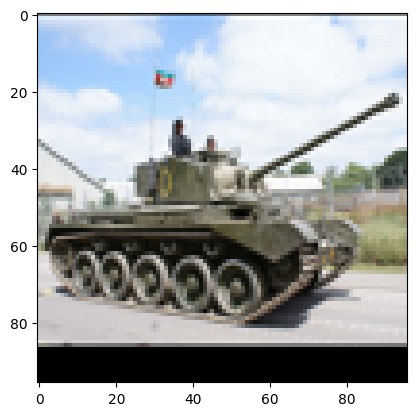

In [16]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [18]:
a,b = test_generator.__getitem__(1)

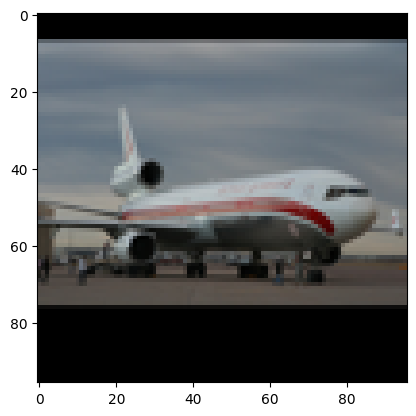

In [19]:
plt.imshow(b[4])

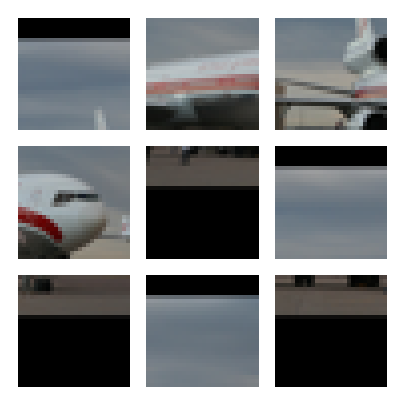

In [20]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [21]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [22]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

2026-06-03 12:20:59.110859: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-06-03 12:20:59.110994: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-03 12:20:59.111004: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-06-03 12:20:59.111253: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-03 12:20:59.111297: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


MAE: tf.Tensor(0.18257158, shape=(), dtype=float32)
std: tf.Tensor(0.0014140933, shape=(), dtype=float32)


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.



